# Exploratory Data Analysis (EDA) - EMSCAD Job Scam Dataset

Notebook ini berdiri sendiri untuk memperkuat bagian EDA pada riset klasifikasi lowongan kerja real/fake. Notebook ini hanya membaca dataset dan membuat visualisasi eksploratif; tidak menjalankan training, tidak mengekspor model, dan tidak mengubah `research_pipeline.ipynb`.

Output utama yang diharapkan ada pada bagian **Top 4 Text Visualization Examples - Job Scam EDA**: panel 2x2 berisi word-cloud style, class-to-keyword flow, categorical flow, dan top-term frequency cloud seperti referensi gambar yang dilampirkan.


## 1. Setup

Dependensi mengikuti paket yang sudah ada di project: `pandas`, `numpy`, `matplotlib`, dan `seaborn`. Visualisasi word-cloud style dibuat langsung dengan Matplotlib supaya tidak perlu menambah dependency baru.


In [1]:
from __future__ import annotations

import html
import math
import re
import subprocess
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch, Rectangle

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "font.size": 10,
})


## 2. Load Dataset

Notebook ini memakai file dataset yang sama dengan pipeline riset: `fake_job_postings.csv`. Letakkan file tersebut di root repository. Jika notebook dijalankan di Google Colab dan file belum ada, cell ini mengikuti pola `research_pipeline.ipynb` untuk mencoba mengunduh dataset.

Target klasifikasi pada EMSCAD adalah kolom `fraudulent`:

- `fraudulent = 0` berarti **Real / Legitimate Job**.
- `fraudulent = 1` berarti **Fake / Fraudulent Job**.

Dengan kata lain, model nantinya belajar dari pasangan **teks lowongan kerja** dan **label real/fake**.

In [2]:
PROJECT_ROOT = Path.cwd()
DATASET_PATH = PROJECT_ROOT / "fake_job_postings.csv"
FIGURES_DIR = PROJECT_ROOT / "artifacts" / "figures"

TEXT_COLUMNS = ["title", "company_profile", "description", "requirements", "benefits"]
CATEGORY_COLUMNS = [
    "telecommuting",
    "has_company_logo",
    "has_questions",
    "employment_type",
    "required_experience",
    "industry",
    "function",
]


def running_in_colab() -> bool:
    try:
        import google.colab  # type: ignore  # noqa: F401
        return True
    except Exception:
        return False


if running_in_colab() and not DATASET_PATH.exists():
    subprocess.run(
        ["gdown", "https://drive.google.com/uc?id=1-Bn_Ey676EijYC3zdzqMIrYgA2FAHaOh", "-O", str(DATASET_PATH)],
        check=True,
    )

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset tidak ditemukan di {DATASET_PATH}. "
        "Letakkan fake_job_postings.csv di root repository, atau jalankan notebook ini di Colab."
    )

df_raw = pd.read_csv(DATASET_PATH)
expected_columns = {"job_id", "fraudulent", *TEXT_COLUMNS}
missing_columns = sorted(expected_columns - set(df_raw.columns))
if missing_columns:
    raise ValueError(f"Dataset kehilangan kolom wajib: {missing_columns}")

display(df_raw.head())
print(f"Rows: {len(df_raw):,} | Columns: {df_raw.shape[1]:,}")


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


Rows: 17,880 | Columns: 18


## 3. Text Preparation and Data Profile

Bagian ini membuat kolom teks gabungan, token bersih, ringkasan distribusi label, missing values, dan panjang teks. Cleaning dibuat ringan karena tujuannya EDA, bukan training ulang.


In [3]:
LABEL_MAP = {
    0: "Real / Legitimate Job",
    1: "Fake / Fraudulent Job",
}
SHORT_LABEL_MAP = {
    0: "Legitimate",
    1: "Fraudulent",
}

BASE_STOPWORDS = {
    "a", "about", "above", "after", "again", "against", "all", "am", "an", "and", "any", "are", "as", "at", "be", "because",
    "been", "before", "being", "below", "between", "both", "but", "by", "can", "could", "did", "do", "does", "doing", "down",
    "during", "each", "few", "for", "from", "further", "had", "has", "have", "having", "he", "her", "here", "hers", "herself",
    "him", "himself", "his", "how", "i", "if", "in", "into", "is", "it", "its", "itself", "just", "me", "more", "most", "my",
    "myself", "no", "nor", "not", "now", "of", "off", "on", "once", "only", "or", "other", "our", "ours", "ourselves", "out",
    "over", "own", "same", "she", "should", "so", "some", "such", "than", "that", "the", "their", "theirs", "them", "themselves",
    "then", "there", "these", "they", "this", "those", "through", "to", "too", "under", "until", "up", "very", "was", "we", "were",
    "what", "when", "where", "which", "while", "who", "whom", "why", "with", "would", "you", "your", "yours", "yourself", "yourselves",
}

DOMAIN_STOPWORDS = {
    "job", "jobs", "work", "working", "worker", "company", "companies", "candidate", "candidates", "position", "positions",
    "role", "roles", "team", "teams", "employee", "employees", "employer", "employment", "office", "business", "service", "services",
    "experience", "required", "requirements", "responsibilities", "skills", "ability", "including", "include", "includes", "using", "use",
    "new", "must", "will", "may", "also", "please", "looking", "based", "within", "provide", "support", "opportunity", "apply",
}

STOPWORDS = BASE_STOPWORDS | DOMAIN_STOPWORDS
TOKEN_PATTERN = re.compile(r"[a-z][a-z']{2,}")


def clean_text(value: object) -> str:
    text = html.unescape(str(value) if value is not None else "")
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s'/-]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def tokenize(text: str) -> list[str]:
    return [token for token in TOKEN_PATTERN.findall(clean_text(text)) if token not in STOPWORDS and len(token) > 2]


def build_counter(texts: pd.Series) -> Counter:
    counter: Counter[str] = Counter()
    for text in texts.fillna(""):
        counter.update(tokenize(text))
    return counter


df = df_raw.copy()
for column in TEXT_COLUMNS:
    df[column] = df[column].fillna("").astype(str)

df["fraudulent"] = df["fraudulent"].astype(int)
df["label"] = df["fraudulent"].map(SHORT_LABEL_MAP)
df["label_full"] = df["fraudulent"].map(LABEL_MAP)
df["combined_text"] = df[TEXT_COLUMNS].agg(" ".join, axis=1).map(clean_text)
df["token_count"] = df["combined_text"].map(lambda text: len(tokenize(text)))
df["char_count"] = df["combined_text"].str.len()

label_mapping = pd.DataFrame(
    {
        "fraudulent": [0, 1],
        "class_label": [LABEL_MAP[0], LABEL_MAP[1]],
        "short_label_used_in_plots": [SHORT_LABEL_MAP[0], SHORT_LABEL_MAP[1]],
        "model_meaning": [
            "Lowongan kerja asli/legitimate",
            "Lowongan kerja palsu/fraudulent",
        ],
    }
)

profile = pd.DataFrame(
    {
        "metric": ["raw_rows", "raw_columns", "prepared_columns", "fraudulent_rows", "fraud_rate", "median_tokens", "median_chars"],
        "value": [
            len(df_raw),
            df_raw.shape[1],
            df.shape[1],
            int(df["fraudulent"].sum()),
            f"{df['fraudulent'].mean():.2%}",
            int(df["token_count"].median()),
            int(df["char_count"].median()),
        ],
    }
)

missing_text = df_raw[TEXT_COLUMNS].isna().sum().rename("missing_rows").to_frame()
missing_text["missing_rate"] = (missing_text["missing_rows"] / len(df_raw)).map(lambda value: f"{value:.2%}")

display(label_mapping)
display(profile)
display(missing_text)


,fraudulent,class_label,short_label_used_in_plots,model_meaning
0,0,Real / Legitimate Job,Legitimate,Lowongan kerja asli/legitimate
1,1,Fake / Fraudulent Job,Fraudulent,Lowongan kerja palsu/fraudulent


,metric,value
0,raw_rows,17880
1,raw_columns,18
2,prepared_columns,23
3,fraudulent_rows,866
4,fraud_rate,4.84%
5,median_tokens,205
6,median_chars,2456


,missing_rows,missing_rate
title,0,0.00%
company_profile,3308,18.50%
description,1,0.01%
requirements,2696,15.08%
benefits,7212,40.34%


## 4. Basic EDA Checks

Visual dasar ini membantu membaca ketidakseimbangan kelas, kelengkapan kolom teks, dan panjang teks per kelas sebelum masuk ke visual teks utama.


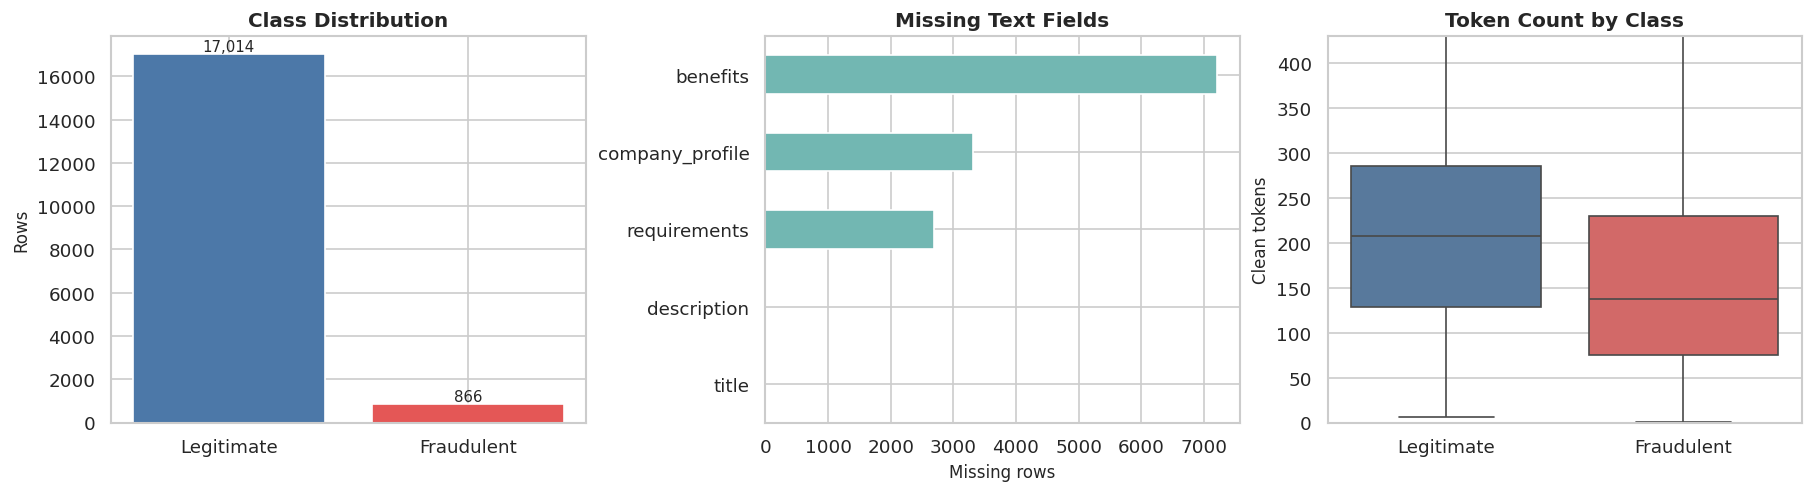

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

label_counts = df["label"].value_counts().reindex(["Legitimate", "Fraudulent"])
axes[0].bar(label_counts.index, label_counts.values, color=["#4c78a8", "#e45756"])
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Rows")
for index, value in enumerate(label_counts.values):
    axes[0].text(index, value, f"{value:,}", ha="center", va="bottom", fontsize=9)

missing_text["missing_rows"].sort_values().plot(kind="barh", ax=axes[1], color="#72b7b2")
axes[1].set_title("Missing Text Fields")
axes[1].set_xlabel("Missing rows")
axes[1].set_ylabel("")

sns.boxplot(
    data=df,
    x="label",
    y="token_count",
    hue="label",
    order=["Legitimate", "Fraudulent"],
    hue_order=["Legitimate", "Fraudulent"],
    ax=axes[2],
    palette=["#4c78a8", "#e45756"],
    dodge=False,
)
if axes[2].legend_ is not None:
    axes[2].legend_.remove()
axes[2].set_title("Token Count by Class")
axes[2].set_xlabel("")
axes[2].set_ylabel("Clean tokens")
axes[2].set_ylim(0, df["token_count"].quantile(0.95))

plt.show()


### Insight from Basic EDA

- **Class Distribution** menjawab apakah dataset seimbang. Pada EMSCAD, kelas fake/fraudulent jauh lebih sedikit daripada real/legitimate, sehingga model tidak cukup dinilai dari accuracy saja. Precision, recall, F1, PR-AUC, dan ROC-AUC tetap dibutuhkan.
- **Missing Text Fields** menunjukkan kolom teks mana yang kosong. Ini penting karena input model dibuat dari gabungan beberapa kolom teks; missing value harus diisi string kosong agar proses cleaning dan tokenisasi tidak gagal.
- **Token Count by Class** menunjukkan panjang teks antar kelas. Jika panjang teks sangat berbeda, model bisa belajar pola panjang dokumen selain pola kata, sehingga informasi ini perlu dipahami sebelum training.

Hasil EDA dasar ini menjelaskan kondisi awal data sebelum masuk ke `research_pipeline.ipynb` untuk split data, training model, dan evaluasi.


## 5. Visualization Helpers

Helper di bawah membuat empat tipe visual teks tanpa dependency tambahan: word-cloud style, flow keyword antar kelas, flow kategori, dan frequency cloud. Layout dibuat deterministik supaya output stabil antar-run.


In [5]:
PALETTE = [
    "#277da1", "#43aa8b", "#f8961e", "#f94144", "#577590", "#90be6d", "#f3722c", "#4d908e", "#b56576", "#6d597a",
]
CLASS_COLORS = {"Legitimate": "#4c78a8", "Fraudulent": "#e45756"}
PANEL_BORDER_COLOR = "#9bb7dc"
PANEL_TITLE_COLOR = "#25476a"
TEXT_DARK = "#263238"


def add_panel_box(ax, title: str) -> None:
    """Draw a reference-style bounding box and title inside an axes panel."""
    ax.set_title("")
    ax.add_patch(
        Rectangle(
            (0, 0),
            1,
            1,
            transform=ax.transAxes,
            fill=False,
            edgecolor=PANEL_BORDER_COLOR,
            linewidth=1.6,
            clip_on=False,
            zorder=30,
        )
    )
    ax.text(
        0.02,
        0.98,
        title,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        weight="bold",
        color=PANEL_TITLE_COLOR,
        bbox={"facecolor": "#f8fbff", "edgecolor": "none", "pad": 1.5},
        zorder=31,
    )


def add_figure_box(fig, color: str = PANEL_BORDER_COLOR) -> None:
    """Draw the light outer frame used by the four-panel reference layout."""
    fig.add_artist(
        Rectangle(
            (0.015, 0.075),
            0.97,
            0.875,
            transform=fig.transFigure,
            fill=False,
            edgecolor=color,
            linewidth=1.8,
            zorder=40,
        )
    )


def scale_value(value: float, min_value: float, max_value: float, low: float, high: float) -> float:
    if math.isclose(max_value, min_value):
        return (low + high) / 2
    return low + (value - min_value) * (high - low) / (max_value - min_value)


def shorten(value: object, max_len: int = 22) -> str:
    text = str(value).strip() if value is not None else "Unknown"
    if not text or text.lower() == "nan":
        text = "Unknown"
    return text if len(text) <= max_len else text[: max_len - 1] + "..."


def draw_curved_line(ax, start: tuple[float, float], end: tuple[float, float], color: str, width: float, alpha: float = 0.35) -> None:
    x0, y0 = start
    x1, y1 = end
    path = MplPath(
        [(x0, y0), (x0 + 0.22, y0), (x1 - 0.22, y1), (x1, y1)],
        [MplPath.MOVETO, MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4],
    )
    ax.add_patch(PathPatch(path, facecolor="none", edgecolor=color, lw=width, alpha=alpha, capstyle="round"))


def draw_text_cloud(
    ax,
    terms: list[tuple[str, int]],
    title: str,
    seed: int = 42,
    max_words: int = 48,
    show_counts: bool = False,
    rotate: bool = True,
) -> None:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    add_panel_box(ax, title)

    terms = [(word, int(count)) for word, count in terms if word and count > 0][:max_words]
    if not terms:
        ax.text(0.5, 0.5, "No terms available", ha="center", va="center", color="#666666")
        return

    rng = np.random.default_rng(seed)
    x_grid = np.linspace(0.08, 0.92, 8)
    y_grid = np.linspace(0.12, 0.88, 6)
    cells = [(x, y) for y in y_grid for x in x_grid]
    rng.shuffle(cells)

    counts = np.array([count for _, count in terms], dtype=float)
    min_count, max_count = float(counts.min()), float(counts.max())

    for index, (word, count) in enumerate(terms[: len(cells)]):
        x, y = cells[index]
        x = float(np.clip(x + rng.uniform(-0.025, 0.025), 0.05, 0.95))
        y = float(np.clip(y + rng.uniform(-0.025, 0.025), 0.08, 0.92))
        fontsize = scale_value(float(count), min_count, max_count, 8, 28)
        rotation = int(rng.choice([0, 0, 0, 90])) if rotate else 0
        label = f"{word}\n({count:,})" if show_counts and fontsize >= 12 else word
        ax.text(
            x,
            y,
            label,
            ha="center",
            va="center",
            fontsize=fontsize,
            color=PALETTE[index % len(PALETTE)],
            alpha=0.92,
            rotation=rotation,
            transform=ax.transAxes,
        )


def distinctive_terms(legit_counter: Counter, fraud_counter: Counter, top_n: int = 10) -> tuple[list[tuple[str, int]], list[tuple[str, int]]]:
    vocab = set(legit_counter) | set(fraud_counter)
    legit_total = sum(legit_counter.values())
    fraud_total = sum(fraud_counter.values())
    vocab_size = max(len(vocab), 1)
    scores = []

    for word in vocab:
        legit_rate = (legit_counter[word] + 1) / (legit_total + vocab_size)
        fraud_rate = (fraud_counter[word] + 1) / (fraud_total + vocab_size)
        score = math.log(fraud_rate / legit_rate)
        scores.append((word, score))

    top_fraud_words = [word for word, _ in sorted(scores, key=lambda item: item[1], reverse=True)[:top_n]]
    top_legit_words = [word for word, _ in sorted(scores, key=lambda item: item[1])[:top_n]]
    return (
        [(word, int(legit_counter[word])) for word in top_legit_words],
        [(word, int(fraud_counter[word])) for word in top_fraud_words],
    )


def rank_distinctive_terms(source_counter: Counter, reference_counter: Counter, top_n: int = 36) -> list[tuple[str, int]]:
    """Return terms that are frequent in one class and relatively uncommon in the other."""
    vocab = set(source_counter) | set(reference_counter)
    source_total = sum(source_counter.values())
    reference_total = sum(reference_counter.values())
    vocab_size = max(len(vocab), 1)
    ranked = []

    for word in vocab:
        source_rate = (source_counter[word] + 1) / (source_total + vocab_size)
        reference_rate = (reference_counter[word] + 1) / (reference_total + vocab_size)
        score = math.log(source_rate / reference_rate)
        ranked.append((word, int(source_counter[word]), score))

    ranked = [item for item in ranked if item[1] > 0]
    ranked.sort(key=lambda item: (item[2], item[1]), reverse=True)
    return [(word, count) for word, count, _ in ranked[:top_n]]


def draw_keyword_flow(ax, legit_terms: list[tuple[str, int]], fraud_terms: list[tuple[str, int]], title: str) -> None:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    add_panel_box(ax, title)

    groups = [
        ("Legitimate", legit_terms, 0.72, np.linspace(0.90, 0.56, max(len(legit_terms), 1))),
        ("Fraudulent", fraud_terms, 0.30, np.linspace(0.45, 0.10, max(len(fraud_terms), 1))),
    ]
    max_count = max([count for _, terms, _, _ in groups for _, count in terms] or [1])

    for label, terms, y_source, y_targets in groups:
        color = CLASS_COLORS[label]
        label_bg = "#edf4fb" if label == "Legitimate" else "#fff1f1"
        ax.text(
            0.045,
            y_source,
            label,
            ha="left",
            va="center",
            color=TEXT_DARK,
            fontsize=8.5,
            weight="bold",
            bbox={"facecolor": label_bg, "edgecolor": color, "boxstyle": "round,pad=0.28", "linewidth": 1.0},
            zorder=4,
        )

        for (word, count), y_target in zip(terms, y_targets):
            width = scale_value(count, 1, max_count, 0.8, 4.0)
            draw_curved_line(ax, (0.20, y_source), (0.78, float(y_target)), color=color, width=width, alpha=0.30)
            ax.text(0.82, float(y_target), f"{word} ({count:,})", ha="left", va="center", fontsize=8, color="#333333")

    ax.text(0.45, 0.50, "distinctive\nterms", ha="center", va="center", fontsize=9, color="#555555")


def draw_categorical_flow(ax, data: pd.DataFrame, title: str, max_rows: int = 9) -> None:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    add_panel_box(ax, title)

    work = data.copy()
    employment_col = "employment_type" if "employment_type" in work.columns else None
    experience_col = "required_experience" if "required_experience" in work.columns else None
    if employment_col is None or experience_col is None:
        ax.text(0.5, 0.5, "Required categorical columns are not available", ha="center", va="center")
        return

    work["employment_group"] = work[employment_col].fillna("Unknown").map(lambda value: shorten(value, 18))
    work["experience_group"] = work[experience_col].fillna("Unknown").map(lambda value: shorten(value, 18))

    flows = (
        work.groupby(["label", "employment_group", "experience_group"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(max_rows)
    )
    if flows.empty:
        ax.text(0.5, 0.5, "No categorical flow data", ha="center", va="center")
        return

    labels = [label for label in ["Legitimate", "Fraudulent"] if label in set(flows["label"])]
    employment_nodes = flows.groupby("employment_group")["count"].sum().sort_values(ascending=False).index.tolist()
    experience_nodes = flows.groupby("experience_group")["count"].sum().sort_values(ascending=False).index.tolist()

    label_y = {label: y for label, y in zip(labels, np.linspace(0.75, 0.28, max(len(labels), 1)))}
    employment_y = {node: y for node, y in zip(employment_nodes, np.linspace(0.88, 0.12, max(len(employment_nodes), 1)))}
    experience_y = {node: y for node, y in zip(experience_nodes, np.linspace(0.88, 0.12, max(len(experience_nodes), 1)))}
    max_count = int(flows["count"].max())

    for _, row in flows.iterrows():
        label = row["label"]
        employment = row["employment_group"]
        experience = row["experience_group"]
        count = int(row["count"])
        color = CLASS_COLORS.get(label, "#666666")
        width = scale_value(count, 1, max_count, 1.0, 6.0)
        draw_curved_line(ax, (0.16, label_y[label]), (0.47, employment_y[employment]), color=color, width=width, alpha=0.26)
        draw_curved_line(ax, (0.53, employment_y[employment]), (0.83, experience_y[experience]), color=color, width=width, alpha=0.26)

    for label, y in label_y.items():
        ax.text(0.04, y, label, ha="left", va="center", fontsize=8, weight="bold", color=CLASS_COLORS.get(label, "#333333"))
    for node, y in employment_y.items():
        ax.text(0.50, y, node, ha="center", va="center", fontsize=8, color="#333333")
    for node, y in experience_y.items():
        ax.text(0.88, y, node, ha="left", va="center", fontsize=8, color="#333333")

    ax.text(0.04, 0.96, "Label", fontsize=8, color="#555555")
    ax.text(0.42, 0.96, "Employment", fontsize=8, color="#555555")
    ax.text(0.78, 0.96, "Experience", fontsize=8, color="#555555")


## 6. Top 4 Text Visualization Examples - Job Scam EDA

Cell ini adalah empat visual teks dalam satu kanvas untuk membaca pola kata dan relasi kategori pada dataset EMSCAD. Panel kanan bawah memakai **distinctive terms** untuk fake/fraudulent job agar lebih relevan daripada sekadar kata yang paling sering muncul.

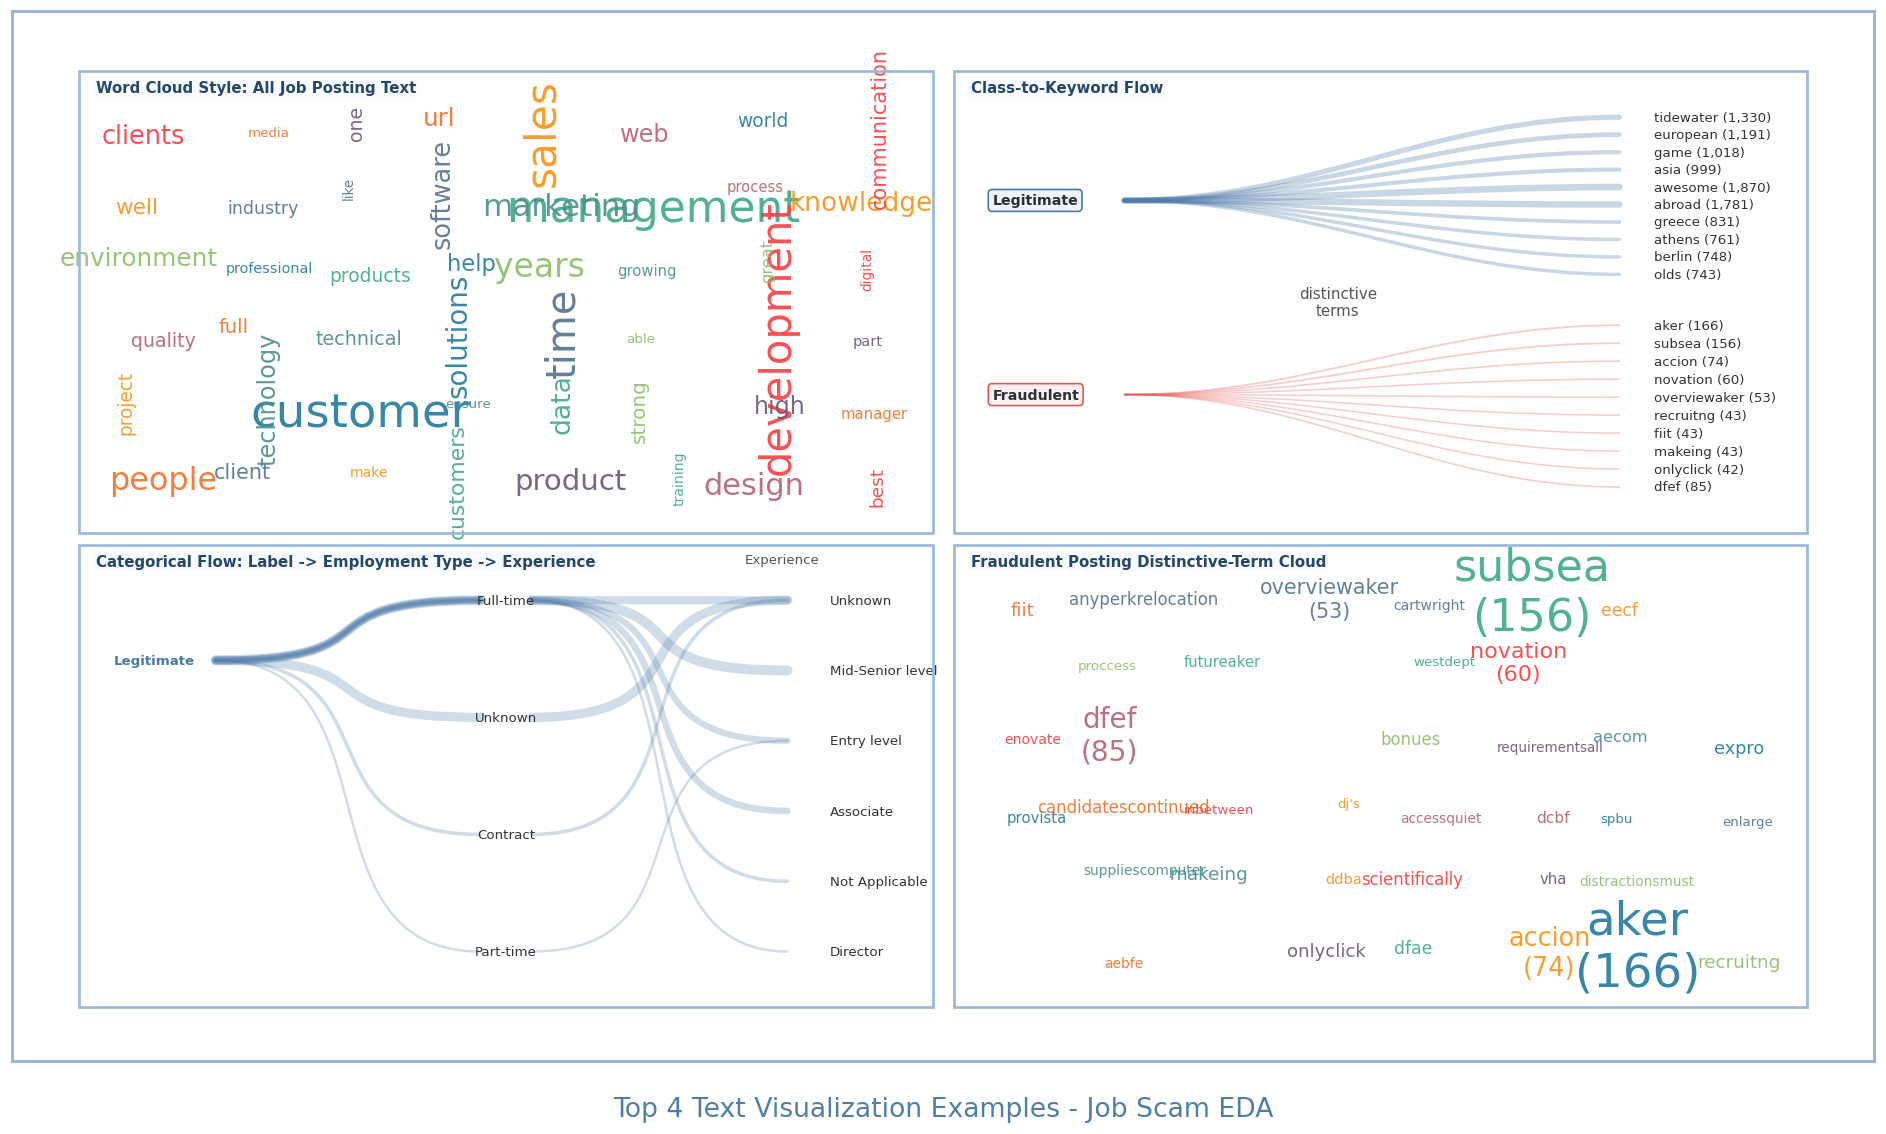

Saved figure to: /content/artifacts/figures/eda_text_visualization_examples.png


In [6]:
all_counter = build_counter(df["combined_text"])
legit_counter = build_counter(df.loc[df["fraudulent"].eq(0), "combined_text"])
fraud_counter = build_counter(df.loc[df["fraudulent"].eq(1), "combined_text"])

legit_distinctive, fraud_distinctive = distinctive_terms(legit_counter, fraud_counter, top_n=10)
fraud_distinctive_cloud_terms = rank_distinctive_terms(fraud_counter, legit_counter, top_n=36)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.subplots_adjust(left=0.05, right=0.95, top=0.90, bottom=0.12, wspace=0.025, hspace=0.025)
add_figure_box(fig)

draw_text_cloud(
    axes[0, 0],
    all_counter.most_common(48),
    "Word Cloud Style: All Job Posting Text",
    seed=7,
    max_words=48,
    show_counts=False,
    rotate=True,
)

draw_keyword_flow(
    axes[0, 1],
    legit_distinctive,
    fraud_distinctive,
    "Class-to-Keyword Flow",
)

draw_categorical_flow(
    axes[1, 0],
    df,
    "Categorical Flow: Label -> Employment Type -> Experience",
    max_rows=9,
)

draw_text_cloud(
    axes[1, 1],
    fraud_distinctive_cloud_terms,
    "Fraudulent Posting Distinctive-Term Cloud",
    seed=19,
    max_words=36,
    show_counts=True,
    rotate=False,
)

OUTPUT_PATH = FIGURES_DIR / "eda_text_visualization_examples.png"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.text(0.5, 0.035, "Top 4 Text Visualization Examples - Job Scam EDA", ha="center", va="center", fontsize=16, color="#4f7ea8")
fig.savefig(OUTPUT_PATH, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {OUTPUT_PATH}")


## 7. Notes for Interpretation

- **Word Cloud Style** menampilkan term paling sering setelah stopword umum dan kata domain yang terlalu generik dibuang. Visual ini memberi gambaran bahasa umum di seluruh lowongan EMSCAD, tetapi belum membedakan real/fake.
- **Class-to-Keyword Flow** membandingkan kata yang lebih khas pada kelas legitimate dan fraudulent. Ini membantu menjelaskan bahwa label `fraudulent` bukan hanya angka, tetapi punya pola teks yang bisa dipelajari model.
- **Categorical Flow** menunjukkan hubungan label dengan `employment_type` dan `required_experience`. Ini membantu melihat apakah metadata lowongan juga memiliki pola yang berbeda antar kelas.
- **Fraudulent Posting Distinctive-Term Cloud** sekarang memakai term yang relatif lebih khas pada fake/fraudulent dibanding legitimate, bukan sekadar kata paling sering. Ini lebih tepat untuk menjelaskan sinyal awal yang mungkin membantu klasifikasi fake job.

EDA ini tidak melatih model, tetapi menjelaskan **mengapa data EMSCAD layak dipakai untuk klasifikasi Real/Fake Job**: dataset memiliki label, teks input, kondisi imbalance yang harus diperhatikan, dan pola kata/kategori yang dapat menjadi sinyal pembeda.

## 8. How EMSCAD Becomes a Real/Fake Job Classifier

Alur konseptual dari dataset EMSCAD sampai menjadi model klasifikasi adalah sebagai berikut:

1. **Dataset dibaca dari `fake_job_postings.csv`.** Setiap baris merepresentasikan satu lowongan kerja.
2. **Label target diambil dari kolom `fraudulent`.** Nilai `0` dipahami sebagai **Real / Legitimate Job**, sedangkan nilai `1` dipahami sebagai **Fake / Fraudulent Job**.
3. **Kolom teks digabung menjadi satu input.** Kolom `title`, `company_profile`, `description`, `requirements`, dan `benefits` digabung menjadi `combined_text`, karena sinyal scam bisa muncul di bagian mana pun dari posting lowongan.
4. **Teks dibersihkan.** HTML, URL, email, simbol berlebih, kapitalisasi, dan whitespace dinormalisasi agar model melihat pola bahasa yang lebih konsisten.
5. **EDA memeriksa kualitas dan pola data.** Distribusi kelas menunjukkan imbalance, missing values menunjukkan kebutuhan handling data kosong, dan visual term/kategori menunjukkan adanya sinyal pembeda antara real dan fake job.
6. **Pipeline training membagi data secara stratified.** Pada `research_pipeline.ipynb`, data dibagi menjadi train, validation, dan test agar proporsi fake/real tetap terjaga di setiap split.
7. **Model belajar dari pasangan input dan label.** Model menerima `combined_text` sebagai input dan `fraudulent` sebagai target, lalu belajar pola yang berkaitan dengan kelas Real atau Fake.
8. **Model dievaluasi dengan metrik klasifikasi.** Karena kelas fake jauh lebih sedikit, evaluasi perlu melihat precision, recall, Fraud F1, PR-AUC, ROC-AUC, dan confusion matrix, bukan hanya accuracy.
9. **Model terlatih dipakai untuk prediksi lowongan baru.** Teks lowongan baru dibersihkan dengan pola yang sama, lalu model mengeluarkan prediksi Real/Fake beserta confidence score.

Dengan demikian, notebook EDA ini menjawab bagian **pemahaman dan justifikasi data**, sedangkan `research_pipeline.ipynb` menjawab bagian **training, evaluasi, dan pemilihan model**.
